In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from utils.data_loader_hai import load_hai_train
from itertools import combinations

x_train, x_test, y_test = load_hai_train()

In [2]:
# -----------------------
# TranAD
# -----------------------
TranAD_scores = pd.read_csv("../Results/HAI TranAD/scores.csv")
TranAD_CV = pd.read_csv("../Results/HAI TranAD/results_cross_validation.csv")

TranAD_threshold = TranAD_CV["mean_threshold"].iloc[0]
TranAD_scores = TranAD_scores.to_numpy().ravel()


# -----------------------
# DeepSVDD
# -----------------------
DeepSVDD_scores = pd.read_csv("../Results/HAI DeepSVDD/scores.csv")
DeepSVDD_CV = pd.read_csv("../Results/HAI DeepSVDD/results_cross_validation.csv")

DeepSVDD_threshold = DeepSVDD_CV["mean_threshold"].iloc[0]
DeepSVDD_scores = DeepSVDD_scores.to_numpy().ravel()



# -----------------------
# COPOD
# -----------------------
COPOD_scores = pd.read_csv("../Results/HAI COPOD/scores.csv")
COPOD_CV = pd.read_csv("../Results/HAI COPOD/results_cross_validation.csv")

COPOD_threshold = COPOD_CV["mean_threshold"].iloc[0]
COPOD_scores = COPOD_scores.to_numpy().ravel()


# -----------------------
# COUTA
# -----------------------
COUTA_scores = pd.read_csv("../Results/HAI COUTA/scores.csv")
COUTA_CV = pd.read_csv("../Results/HAI COUTA/results_cross_validation.csv")

COUTA_threshold = COUTA_CV["mean_threshold"].iloc[0]
COUTA_scores = COUTA_scores.to_numpy().ravel()


# -----------------------
# LOF
# -----------------------
LOF_scores = pd.read_csv("../Results/HAI LOF/scores.csv")
LOF_CV = pd.read_csv("../Results/HAI LOF/results_cross_validation.csv")

LOF_threshold = LOF_CV["mean_threshold"].iloc[0]
LOF_scores = LOF_scores.to_numpy().ravel()


# -----------------------
# TcnED
# -----------------------
TcnED_scores = pd.read_csv("../Results/HAI TcnED/scores.csv")
TcnED_CV = pd.read_csv("../Results/HAI TcnED/results_cross_validation.csv")

TcnED_threshold = TcnED_CV["mean_threshold"].iloc[0]
TcnED_scores = TcnED_scores.to_numpy().ravel()

In [3]:
# Get predictions from scores and threshold
TranAD_predictions = (TranAD_scores>TranAD_threshold).astype(int)
DeepSVDD_predictions = (DeepSVDD_scores > DeepSVDD_threshold).astype(int)
COPOD_predictions = (COPOD_scores > COPOD_threshold).astype(int)
COUTA_predictions = (COUTA_scores > COUTA_threshold).astype(int)
LOF_predictions = (LOF_scores > LOF_threshold).astype(int)
TcnED_predictions = (TcnED_scores > TcnED_threshold).astype(int)

In [4]:
predictions_dict = {
    "TranAD": TranAD_predictions,
    "DeepSVDD": DeepSVDD_predictions,
    "COPOD": COPOD_predictions,
    "COUTA": COUTA_predictions,
    "LOF": LOF_predictions,
    "TcnED": TcnED_predictions,
}


predictions2_dict = {
    "TranAD": {
        "predictions": TranAD_predictions,
        "scores": TranAD_scores
    },
    "DeepSVDD": {
        "predictions": DeepSVDD_predictions,
        "scores": DeepSVDD_scores
    },
    "COPOD": {
        "predictions": COPOD_predictions,
        "scores": COPOD_scores
    },
    "COUTA": {
        "predictions": COUTA_predictions,
        "scores": COUTA_scores
    },
    "LOF": {
        "predictions": LOF_predictions,
        "scores": LOF_scores
    },
    "TcnED": {
        "predictions": TcnED_predictions,
        "scores": TcnED_scores
    }
}

In [5]:
def summarize(scores):
    mean = np.mean(scores)
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    std = np.std(scores)
    return mean, std, lower, upper

In [6]:
n_bootstraps = 50
rng = np.random.RandomState(42)
results = {}

for name, model_data in predictions2_dict.items():
    predictions = model_data["predictions"]
    scores = model_data["scores"]
    print(name)
    roc_scores = []
    pr_scores = []
    f1_scores = []

    # Split by class
    pos_idx = np.where(y_test == 1)[0]
    neg_idx = np.where(y_test == 0)[0]

    for i in range(n_bootstraps):
        # Sample within each class
        boot_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True)
        boot_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True)

        indices = np.concatenate([boot_pos, boot_neg])

        roc_scores.append(
            roc_auc_score(y_test[indices], scores[indices])
        )

        pr_scores.append(
            average_precision_score(y_test[indices], scores[indices])
        )

        f1_scores.append(
            f1_score(y_test[indices], predictions[indices])
        )
    results[name] = {
        "ROC": summarize(roc_scores),
        "PR": summarize(pr_scores),
        "F1": summarize(f1_scores),
    }


TranAD
DeepSVDD
COPOD
COUTA
LOF
TcnED


In [7]:
for name, metrics in results.items():

    roc_mean, roc_std, roc_low, roc_high = metrics["ROC"]
    pr_mean, pr_std, pr_low, pr_high = metrics["PR"]
    f1_mean, f1_std, f1_low, f1_high = metrics["F1"]

    print(f"\n=== {name} ===")

    print(f"AUC-ROC: {roc_mean:.4f} (95% CI: {roc_low:.4f}–{roc_high:.4f})")
    print(f"AUC-PR : {pr_mean:.4f} (95% CI: {pr_low:.4f}–{pr_high:.4f})")
    print(f"F1     : {f1_mean:.4f} (95% CI: {f1_low:.4f}–{f1_high:.4f})")


=== TranAD ===
AUC-ROC: 0.6036 (95% CI: 0.5949–0.6130)
AUC-PR : 0.1694 (95% CI: 0.1576–0.1782)
F1     : 0.0791 (95% CI: 0.0717–0.0877)

=== DeepSVDD ===
AUC-ROC: 0.4716 (95% CI: 0.4632–0.4813)
AUC-PR : 0.0817 (95% CI: 0.0755–0.0886)
F1     : 0.0611 (95% CI: 0.0607–0.0616)

=== COPOD ===
AUC-ROC: 0.6618 (95% CI: 0.6504–0.6698)
AUC-PR : 0.1065 (95% CI: 0.0981–0.1139)
F1     : 0.1298 (95% CI: 0.1197–0.1377)

=== COUTA ===
AUC-ROC: 0.6083 (95% CI: 0.5985–0.6169)
AUC-PR : 0.1798 (95% CI: 0.1709–0.1896)
F1     : 0.1000 (95% CI: 0.0862–0.1115)

=== LOF ===
AUC-ROC: 0.7956 (95% CI: 0.7904–0.8028)
AUC-PR : 0.3416 (95% CI: 0.3315–0.3521)
F1     : 0.3911 (95% CI: 0.3760–0.4041)

=== TcnED ===
AUC-ROC: 0.6338 (95% CI: 0.6258–0.6424)
AUC-PR : 0.1694 (95% CI: 0.1594–0.1779)
F1     : 0.1168 (95% CI: 0.1034–0.1272)


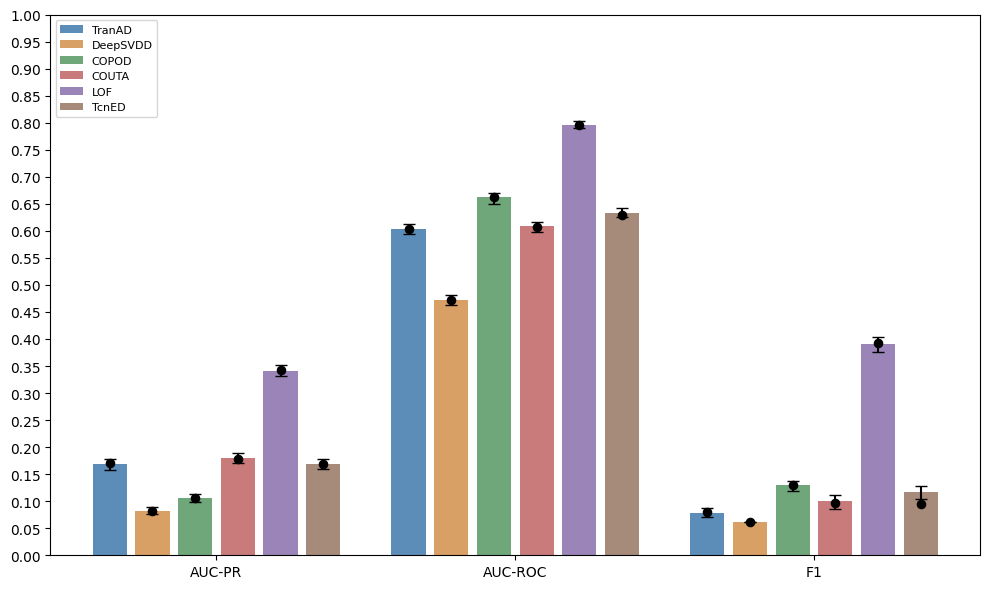

In [8]:
import numpy as np
import matplotlib.pyplot as plt

test_results = { "DeepSVDD": {
        "PR": 0.0820,
        "ROC": 0.4724,
        "F1": 0.0612,
    },
    "TranAD": {
        "PR": 0.1698,
        "ROC": 0.6029,
        "F1": 0.0795,
    },
    "COUTA": {
        "PR": 0.1774,
        "ROC": 0.6064,
        "F1": 0.0968,
    },
    "COPOD": {
        "PR": 0.1063,
        "ROC": 0.6618,
        "F1": 0.1295,
    },
    "LOF": {
        "PR": 0.3424,
        "ROC": 0.7950,
        "F1": 0.3921,
    },
    "TcnED": {
        "PR": 0.1684,
        "ROC": 0.6300,
        "F1": 0.0952,
    },
}

plt.style.use('default')

models = list(results.keys())

metrics_to_plot = ["PR", "ROC", "F1"]
metric_labels = ["AUC-PR", "AUC-ROC", "F1"]

colors = ['#5B8DB8', '#D9A066', '#6FA77B', '#C97A7A', '#9A84B8', '#A68A7A']

group_gap = 1
x_groups = []

start = 0
for _ in metrics_to_plot:
    x = np.arange(len(models)) + start
    x_groups.append(x)
    start = x[-1] + group_gap + 1

fig, ax = plt.subplots(figsize=(10, 6))

for metric_idx, metric in enumerate(metrics_to_plot):
    x_positions = x_groups[metric_idx]

    scores = np.array([results[m][metric][0] for m in models])
    lows   = np.array([results[m][metric][2] for m in models])
    highs  = np.array([results[m][metric][3] for m in models])

    yerr = np.vstack([
        np.maximum(scores - lows, 0),
        np.maximum(highs - scores, 0)
    ])

    for i, model in enumerate(models):
        ax.bar(
            x_positions[i],
            scores[i],
            yerr=yerr[:, i:i+1],
            capsize=4,
            color=colors[i % len(colors)],
            label=model if metric_idx == 0 else None,
            error_kw={'ecolor': 'black'}
        )
        test_value = test_results[model][metric]

        ax.scatter(
            x_positions[i],
            test_value,
            color='black',
            s=35,
            zorder=3
        )

ax.set_xticks([x.mean() for x in x_groups])
ax.set_xticklabels(metric_labels)

ax.legend(
    loc='upper left',
    fontsize=8
)

ax.grid(False)
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.01, 0.05))

plt.tight_layout()
plt.savefig("bootstrapping_hai.png", dpi=300, bbox_inches="tight")
fig.savefig("bootstrapping_hai.pdf", bbox_inches="tight")
plt.show()